<a href="https://colab.research.google.com/github/sripavan24/cnn-ann_deep_L/blob/main/cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import numpy as np

In [ ]:
(x_train,y_train),(x_test,y_test)=datasets.cifar10.load_data()

In [ ]:
x_train.shape

(50000, 32, 32, 3)

In [ ]:
x_test.shape

(10000, 32, 32, 3)

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
y_train=y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [ ]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

In [ ]:
def plot_sample(x,y,index):
  plt.figure(figsize=(15,2))
  plt.imshow(x[index])
  plt.xlabel(class_names[y[index]])
plt.show()

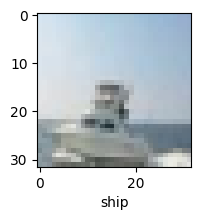

In [ ]:
plot_sample(x_train,y_train,100)

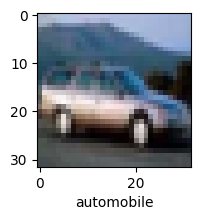

In [ ]:
plot_sample(x_train,y_train,4)

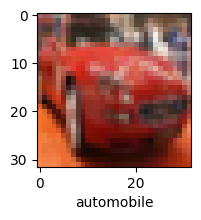

In [ ]:
plot_sample(x_train,y_train,5)

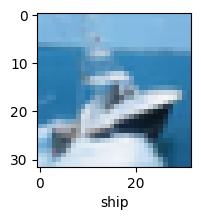

In [ ]:
plot_sample(x_train,y_train,8)

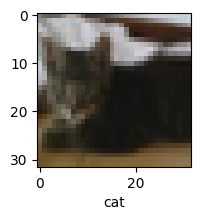

In [ ]:
plot_sample(x_train,y_train,9)

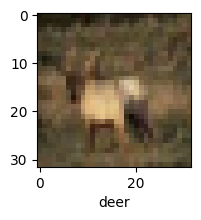

In [ ]:
plot_sample(x_train,y_train,3)

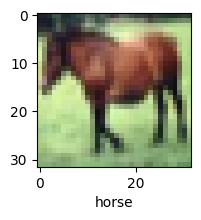

In [ ]:
plot_sample(x_train,y_train,7)

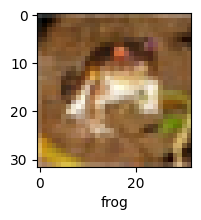

In [ ]:
plot_sample(x_train,y_train,0)

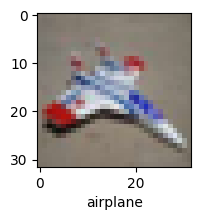

In [ ]:
plot_sample(x_train,y_train,30)

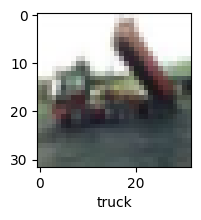

In [ ]:
plot_sample(x_train,y_train,2)

In [ ]:
x_train=x_train/255.0
x_test=x_test/255.0

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# data augementation
augementation=ImageDataGenerator(rotation_range=20,
                                 width_shift_range=0.1,
                                 height_shift_range=0.1,
                                 shear_range=0.1,
                                 zoom_range=0.1,
                                 horizontal_flip=True,
                                 fill_mode='nearest'
                                 )

In [ ]:
cnn=models.Sequential([
  layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(32,32,3)),
  layers.BatchNormalization(),
  layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu'),
  layers.MaxPooling2D((2,2)),
  layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu'),
  layers.BatchNormalization(),
  layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu'),
  layers.MaxPooling2D((2,2)),
  #dense
  layers.Flatten(),
  layers.Dense(128,activation='relu'),
  layers.Dense(128,activation='relu'),
  layers.Dropout(0.25),
  layers.Dense(10,activation='softmax')

])

In [ ]:
cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

In [ ]:
x_valid = x_train[:25000] / 255.0
y_valid = y_train[:25000]

x_train = x_train[25000:] / 255.0
y_train = y_train[25000:]

In [ ]:
x_valid.shape

(25000, 32, 32, 3)

In [ ]:
cnn.fit(
    x_train,y_train,
        epochs=20,
    validation_data=(x_train,y_train))

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.4084 - loss: 1.6287 - val_accuracy: 0.4762 - val_loss: 1.7254
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6532 - loss: 0.9870 - val_accuracy: 0.6608 - val_loss: 0.9964
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7159 - loss: 0.8166 - val_accuracy: 0.6626 - val_loss: 0.9737
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.7602 - loss: 0.7004 - val_accuracy: 0.7723 - val_loss: 0.6638
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7777 - loss: 0.6469 - val_accuracy: 0.8006 - val_loss: 0.5668
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8057 - loss: 0.5639 - val_accuracy: 0.7674 - val_loss: 0.6767
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8254 - loss: 0.5131 - val_accuracy: 0.8397 - val_loss: 0.4712
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8403 - loss: 

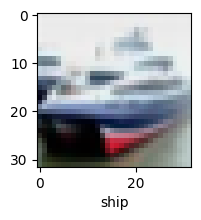

In [ ]:
y_test=y_test.reshape(-1,)
plot_sample(x_test,y_test,1)

In [ ]:
y_pred=cnn.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [ ]:
y_pred[:5]

array([[1.88718249e-10, 5.07313691e-10, 1.09823013e-05, 9.98186052e-01,
        4.22148696e-06, 1.53841602e-03, 2.60219211e-04, 1.75113001e-07,
        3.67328497e-08, 1.81484494e-09],
       [5.09742240e-04, 8.93470228e-01, 5.78495337e-06, 4.76140286e-07,
        1.54255716e-07, 1.17394698e-08, 7.02833631e-06, 2.27464436e-10,
        1.05128780e-01, 8.77854472e-04],
       [2.73322348e-05, 1.15692674e-05, 3.75391282e-05, 1.63656168e-05,
        2.69650400e-06, 1.98231632e-07, 7.77022433e-06, 1.42795242e-08,
        9.99895692e-01, 8.42966188e-07],
       [1.11594394e-01, 3.62604283e-06, 1.77597703e-05, 2.99555509e-08,
        3.96363937e-08, 2.22343696e-13, 6.30540065e-10, 1.15596248e-12,
        8.88384163e-01, 6.27409236e-09],
       [1.31126021e-09, 6.24966355e-12, 5.25415780e-05, 7.43083598e-04,
        8.42993140e-01, 2.06713230e-05, 1.56190470e-01, 1.06642730e-07,
        1.31323485e-09, 6.62760818e-11]], dtype=float32)

In [ ]:
n=[np.argmax(i) for i in y_pred]
n[:20]

[np.int64(3),
 np.int64(1),
 np.int64(8),
 np.int64(8),
 np.int64(4),
 np.int64(6),
 np.int64(1),
 np.int64(6),
 np.int64(3),
 np.int64(9),
 np.int64(4),
 np.int64(9),
 np.int64(3),
 np.int64(7),
 np.int64(9),
 np.int64(8),
 np.int64(3),
 np.int64(7),
 np.int64(8),
 np.int64(6)]

In [ ]:
y_test[:20]

array([3, 8, 8, 0, 6, 6, 1, 6, 3, 1, 0, 9, 5, 7, 9, 8, 5, 7, 8, 6],
      dtype=uint8)

In [ ]:
class_names[n[67]]

'bird'

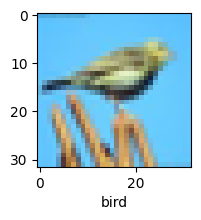

In [ ]:
plot_sample(x_test,y_test,67)

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix

In [ ]:
print(classification_report(y_test,n))

              precision    recall  f1-score   support

           0       0.77      0.75      0.76      1000
           1       0.88      0.88      0.88      1000
           2       0.64      0.59      0.61      1000
           3       0.46      0.69      0.55      1000
           4       0.72      0.63      0.67      1000
           5       0.67      0.59      0.63      1000
           6       0.74      0.84      0.79      1000
           7       0.84      0.74      0.79      1000
           8       0.86      0.81      0.83      1000
           9       0.89      0.80      0.84      1000

    accuracy                           0.73     10000
   macro avg       0.75      0.73      0.74     10000
weighted avg       0.75      0.73      0.74     10000

